In [90]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Assuming files are stored in "saved-fees-updated" directory
data_dir = '../coin-selection-c-master/simulation/results'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# Predefined colors for each strategy
strategy_colors = {
#    'MAX_BILLS': 'blue',
#    'CLOSEST_TO_EXPIRE_MIN_BILLS': 'orange',
#    'CLOSEST_TO_EXPIRE_MAX_BILLS': 'cyan',
#    'MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED': 'blue',
    'RANDOM': 'magenta',
#    'MIN_BILLS': 'blue',
#    'EVEN_FROM_MIN_TO_MAX': 'red',
#    'EVEN_FROM_MAX_TO_MIN': 'pink',
    'WALLET_CORE': 'cyan',
    'GREEDY_MIN_TO_MAX_FIX': 'red',
    'GREEDY_MAX_TO_MIN_FIX': 'orange',
    'CALL_EXTERNAL': 'black'
}

# Initialize an empty list to hold all data
all_data = []

# Process each file
for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        # Read user type and strategy from the first line
        user_type, strategy = file.readline().strip().split(', ')
        
        # Parse the rest of the data
        for line in file:
            id, time, amount, operation, fee, coin_count, *_ = line.strip().split(', ')  # Updated here to include 'amount'
            all_data.append({
                "UserType": user_type,
                "Strategy": strategy,
                "Id": id,
                "Time": int(time),
                "Amount": int(amount),  
                "Operation": operation,  
                "Fee": int(fee),
                "FileName": file_name,
                "CoinCount": int(coin_count)
            })
        

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)


# Filter out DEPOSIT_REFRESH_OP right away
#df = df[(df['Operation'] != 'DEPOSIT_REFRESH_OP') & (df['Amount'] > 0)] # removed "& (df['Amount'] < 500000)" here

df['Days'] = df['Time']/3600/24

# df.set_index("Days", inplace=True)

user_types = df["UserType"].unique()
strategies = df["Strategy"].unique()

n_user_types = df["UserType"].nunique()
n_strats = df["Strategy"].nunique()

cols = min(n_user_types, 2)
rows = np.ceil(n_user_types / cols).astype(int)

df["SignAmount"] = 0
df["SignAmount"] = df['Amount'].where(df["Operation"] == "WITHDRAW_OP", -df["Amount"]) - df["Fee"]

file_groups = df.groupby('FileName')
df["Balance"] = file_groups['SignAmount'].cumsum()
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()
fees_by_op = df.groupby(["UserType", "Strategy", "Operation"])["Fee"].sum()

#print(file_groups["CoinCount"].shift(1, fill_value=0) - file_groups["CoinCount"])
df["UsedDiskSpace"] = df["CoinCount"]
df["UsedBandwidth"] = 0
df["UsedBandwidth"] = df.groupby(['FileName', 'UserType', 'Strategy'])["CoinCount"].diff().abs().fillna(0).groupby(df['Strategy']).cumsum()

df["FeeSumWallet"] = df["CoinCount"] + df["CumulativeFee"]
print(df.loc[(df["Strategy"] == 'GREEDY_MAX_TO_MIN_FIX') & (df["UserType"] == 'BALANCED_ARTIST')][["Time","CumulativeFee", "Amount", "Fee", "Balance"]])
print(df.loc[(df["Strategy"] == 'GREEDY_MIN_TO_MAX_FIX') & (df["UserType"] == 'BALANCED_ARTIST')][["Time", "CumulativeFee", "Amount", "Fee", "Balance"]])

Empty DataFrame
Columns: [Time, CumulativeFee, Amount, Fee, Balance]
Index: []
            Time  CumulativeFee   Amount  Fee   Balance
172373         0              9  1000000    9    999991
172374         0             10    25081    1    974909
172375         0             11        0    1    974908
172376     86400             20    43333    9   1018232
172377     86400             21    21429    1    996802
...          ...            ...      ...  ...       ...
175006  93139200           6249    22318    1  12424097
175007  93139200           6250        0    1  12424096
175008  93225600           6258        0    8  12424088
175009  93225600           6259    18707    1  12405380
175010  93225600           6260        0    1  12405379

[2638 rows x 5 columns]


In [91]:
# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(5, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

def plot_grid(key):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)
    
    axes = axes.ravel()
    
    for idx, (user_type, ax) in enumerate(zip(sorted(user_types), axes)):
        # Prepare boxplot data; collect lists from each cell in row corresponding to user type
        for strategy in strategies:
            #ax.bar(boxplot_data, tick_labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
            current_data = df[(df["UserType"] == user_type) & (df["Strategy"] == strategy)]
            current_data.plot(y=key, xlabel="Simulation Time (days)", ylabel="Satoshis", label=strategy,
                              ylim=(df[key].min(), df[key].max()), ax=ax)
            ax.set_title(f"User Type: {user_type}", fontsize=26)
            ax.set_ylabel(key, fontsize=22)
            ax.tick_params(axis='x', rotation=45, labelsize=13)
    
    plt.tight_layout()
    # plt.savefig("results/final_cumulative_fees", bbox_inches='tight')
    plt.show()
    return fig

    

# Cumulative Fee

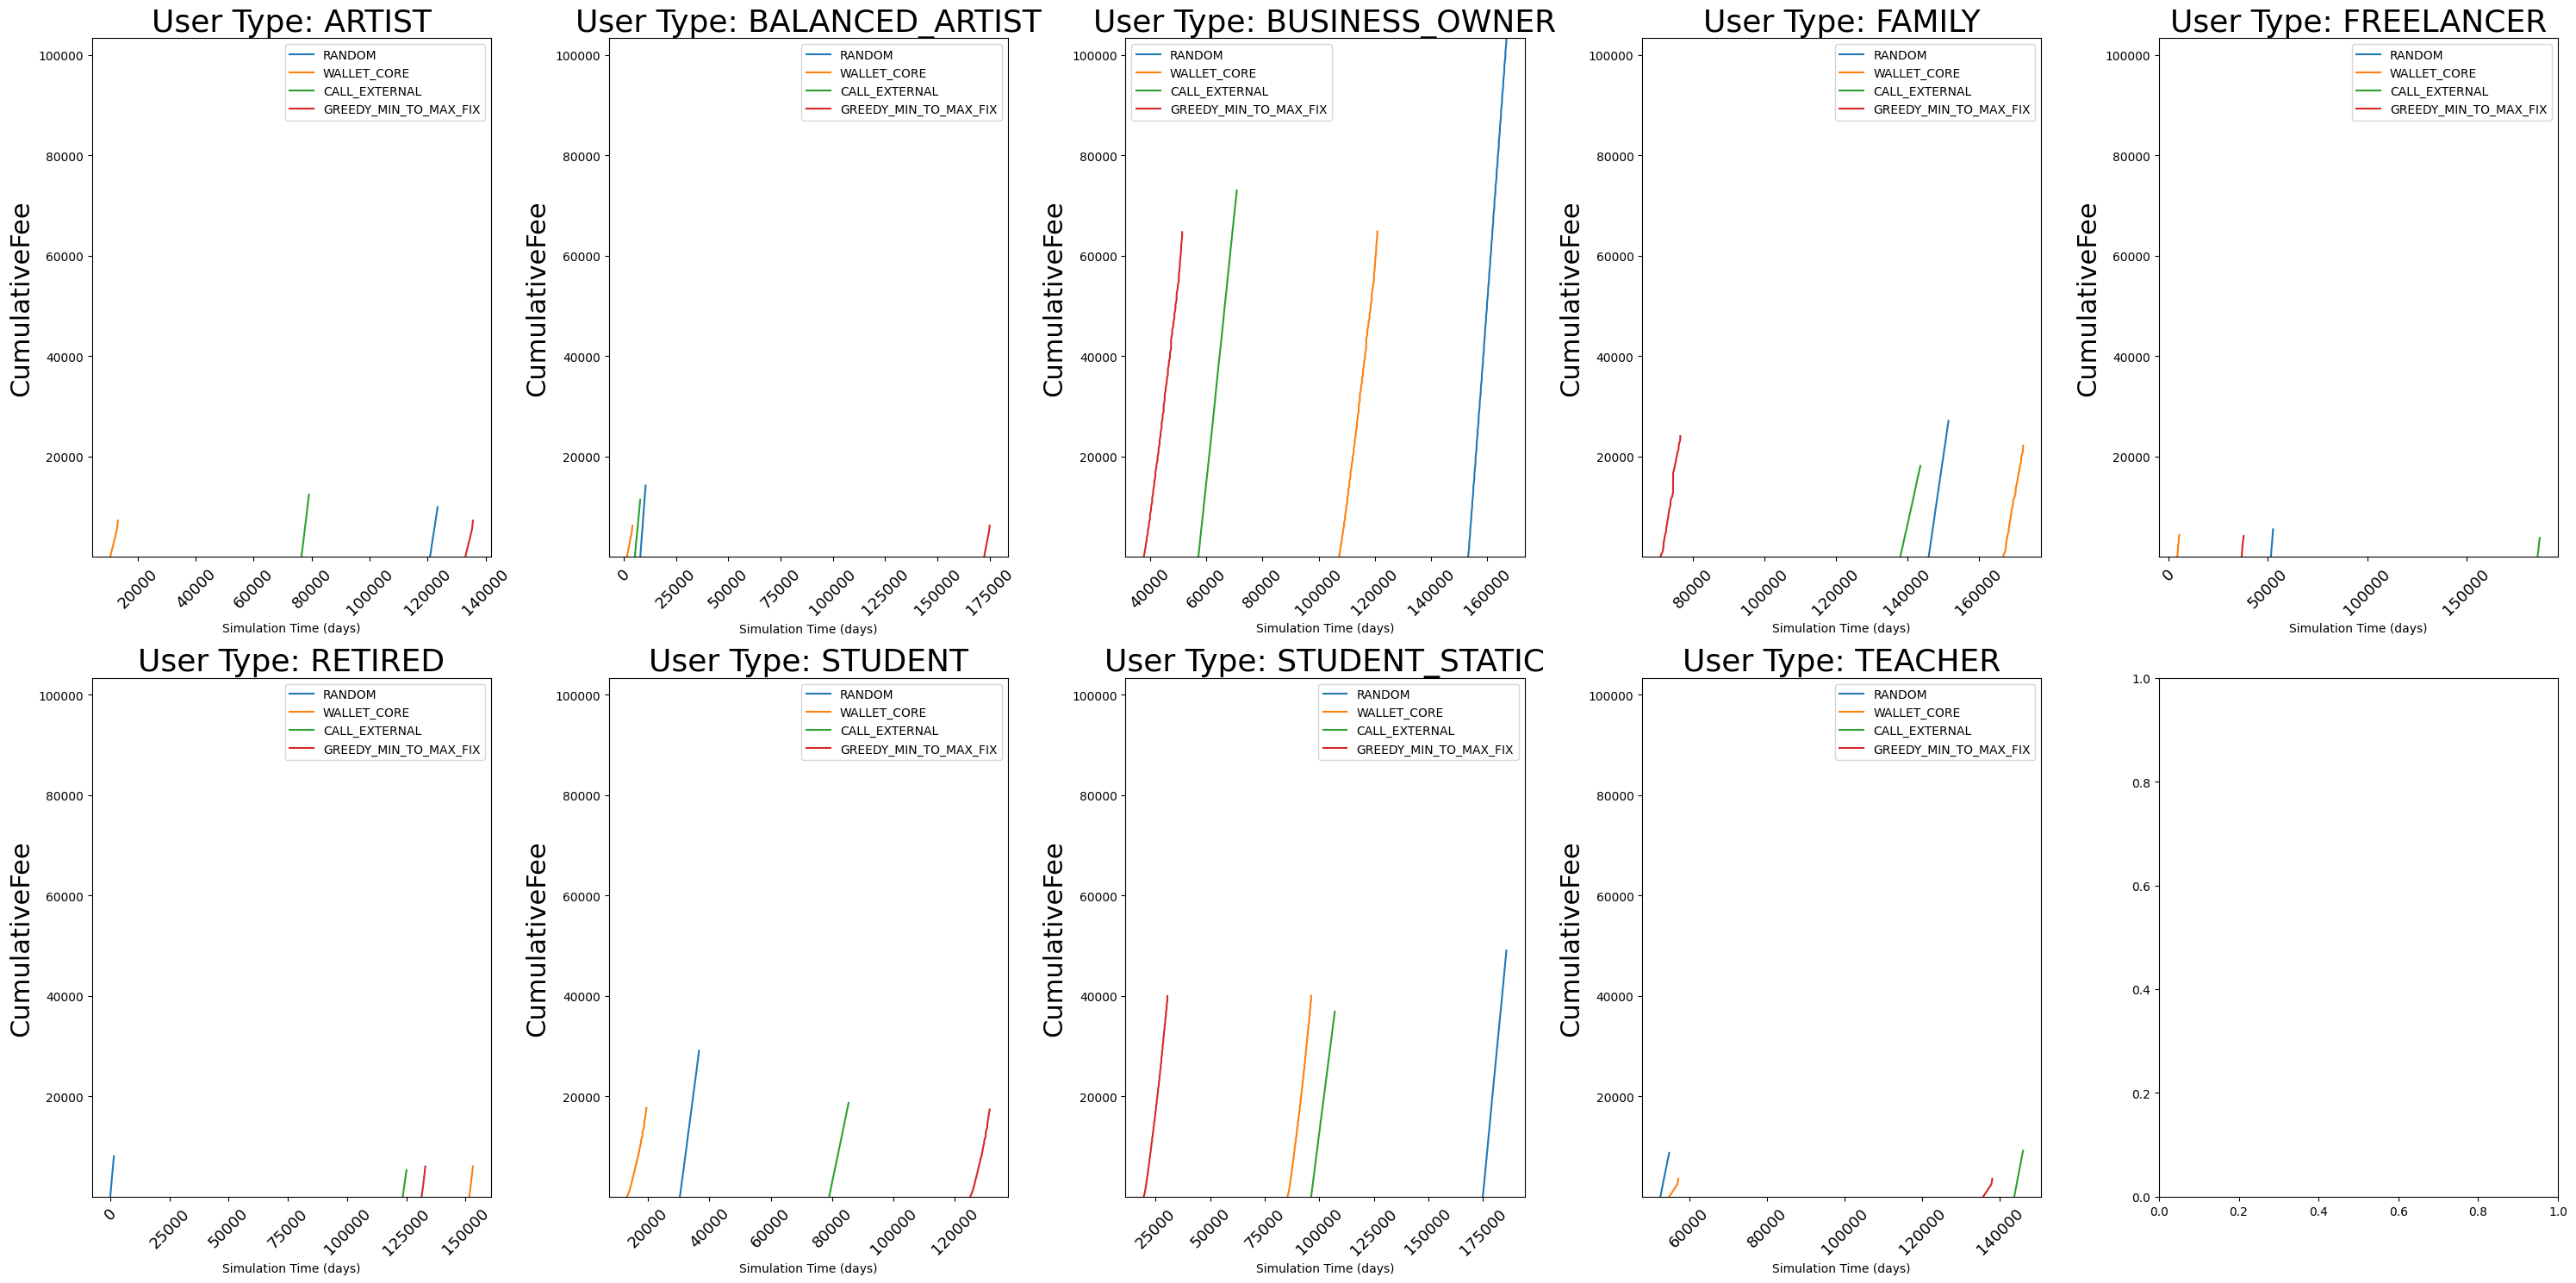

In [92]:
# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

fig = plot_grid("CumulativeFee")
fig.savefig("results/fee_cum_unit", bbox_inches='tight', dpi=300)

# Composition

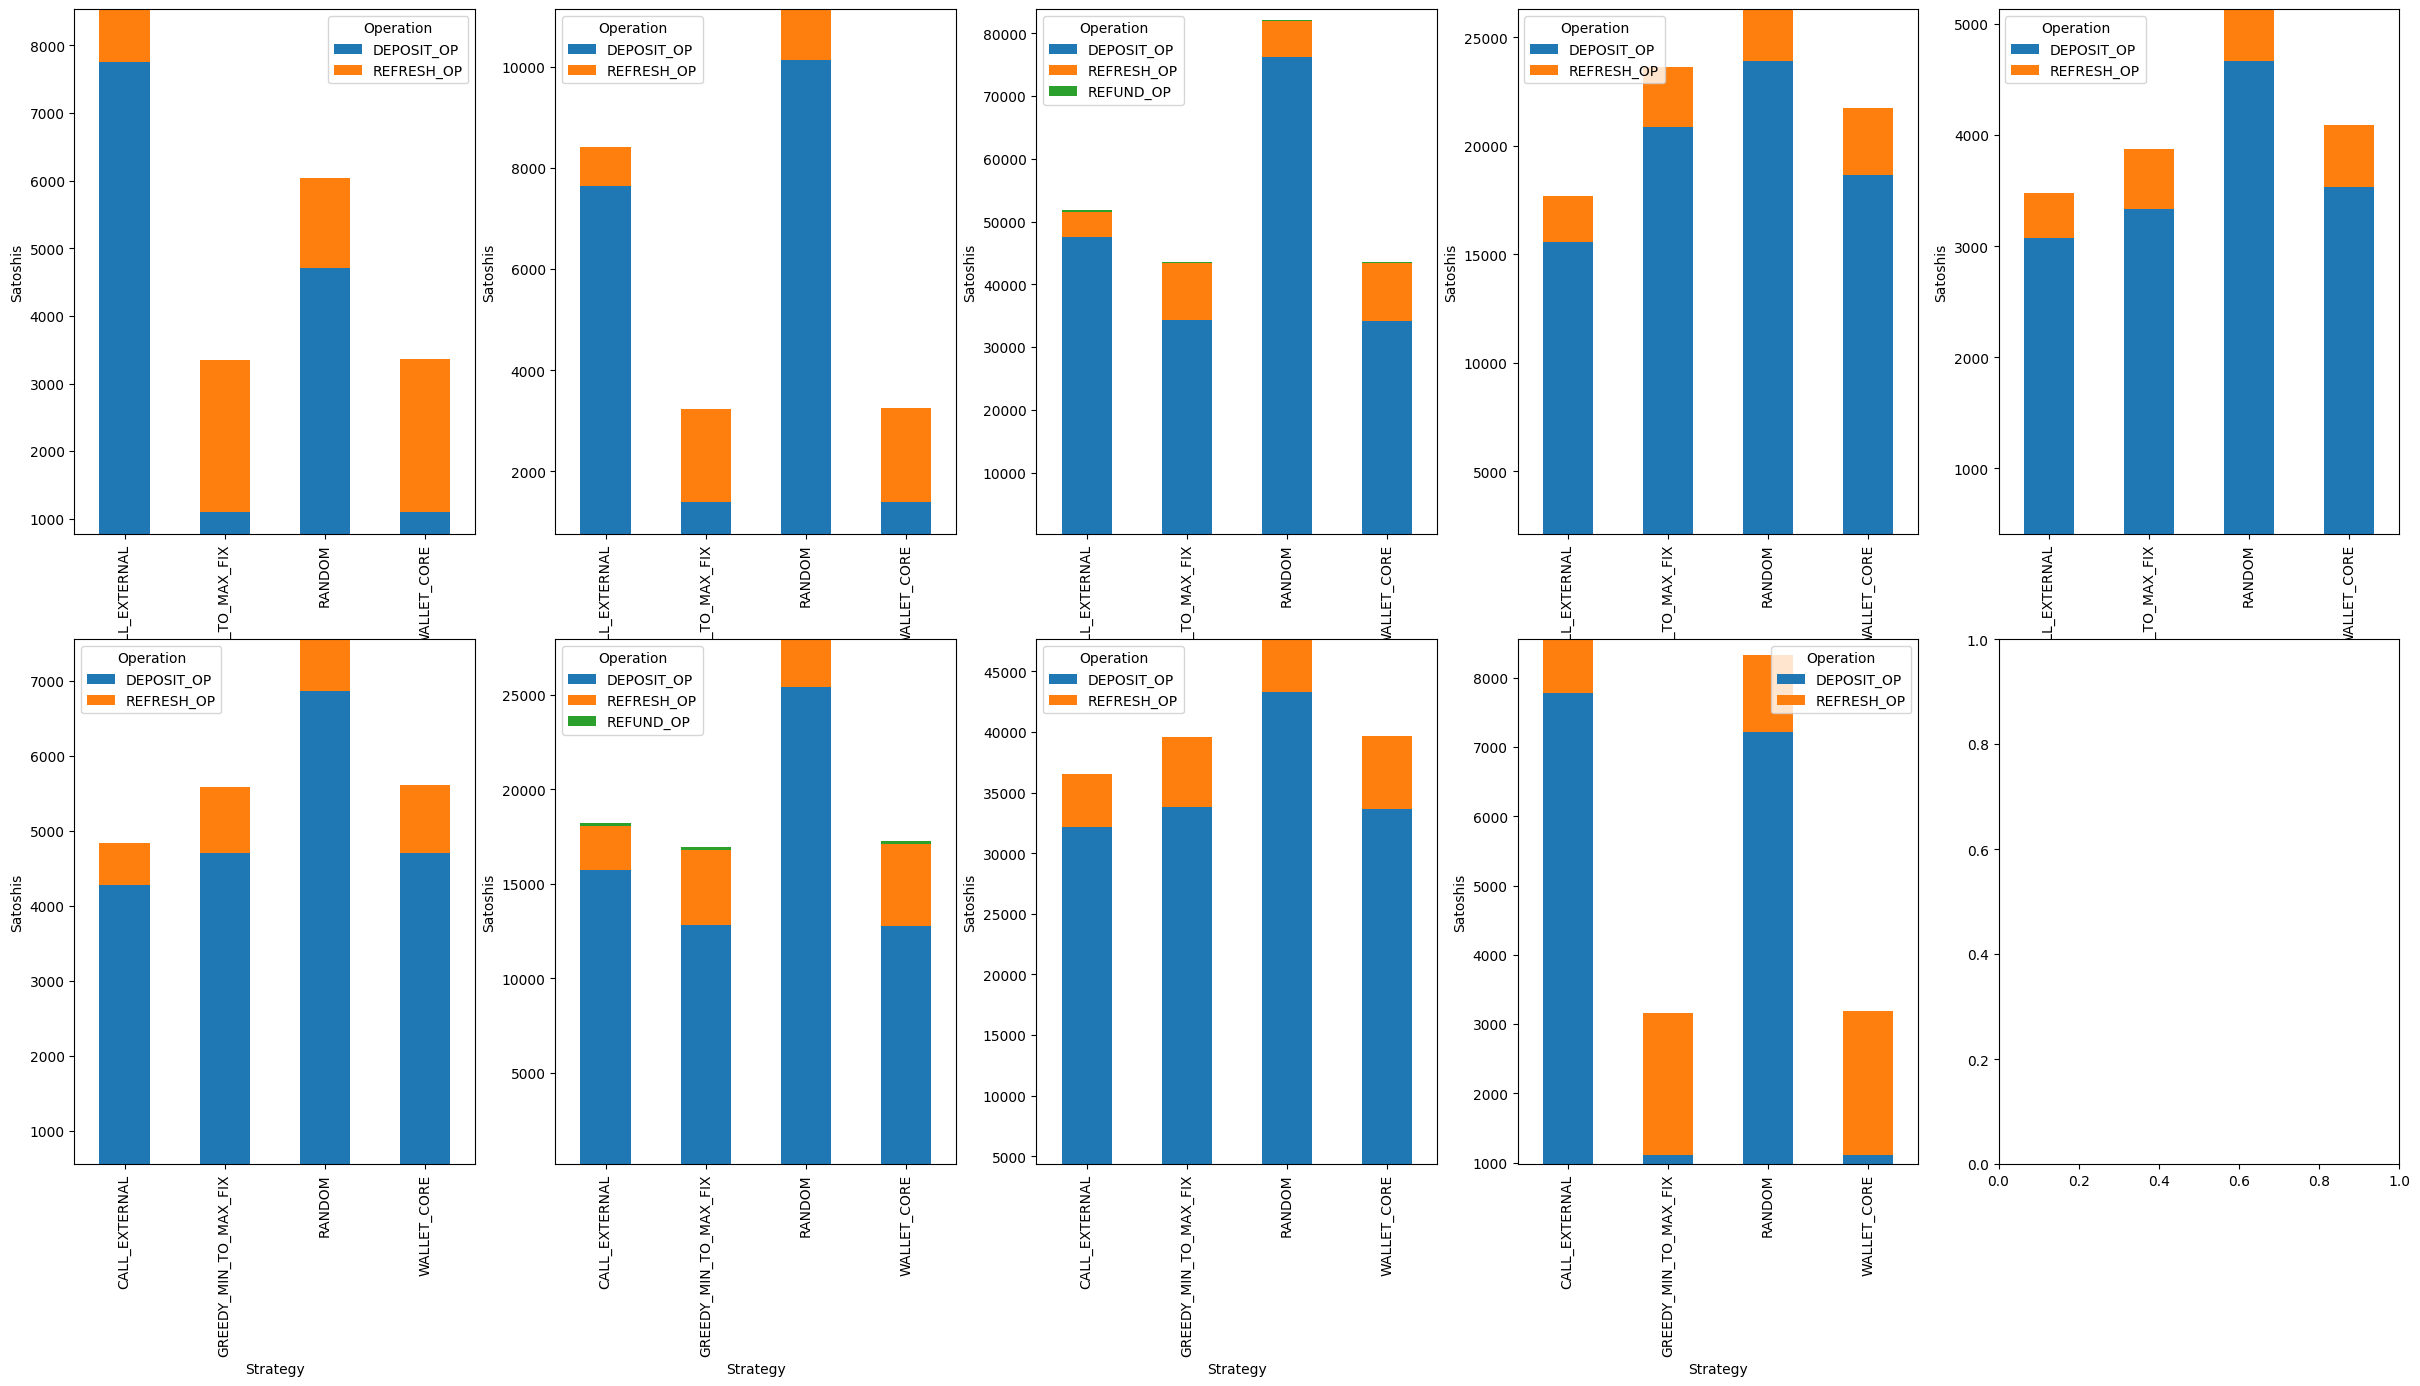

In [93]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)
axes = axes.flatten()
fees_by_op = df.groupby(["UserType", "Strategy", "Operation"])["Fee"].sum().unstack(fill_value=0)
ops = df["Operation"].unique()

for idx, (user_type, ax) in enumerate(zip(sorted(user_types), axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type

    current_data = df[(df["UserType"] == user_type) & (df["Operation"] != "WITHDRAW_OP")]
    plot_data = current_data.sort_values(["Strategy", "Operation"]).groupby(["Strategy", "Operation"])["Fee"].sum()
    minmax = plot_data.min(axis=None), plot_data.max(axis=None) * 1.1
    fig = plot_data.unstack().plot(kind="bar", ylim=minmax, stacked=True, ylabel="Satoshis", ax=ax).get_figure()

fig.savefig("results/fee_comp_unit", bbox_inches='tight', dpi=300)

# Resources

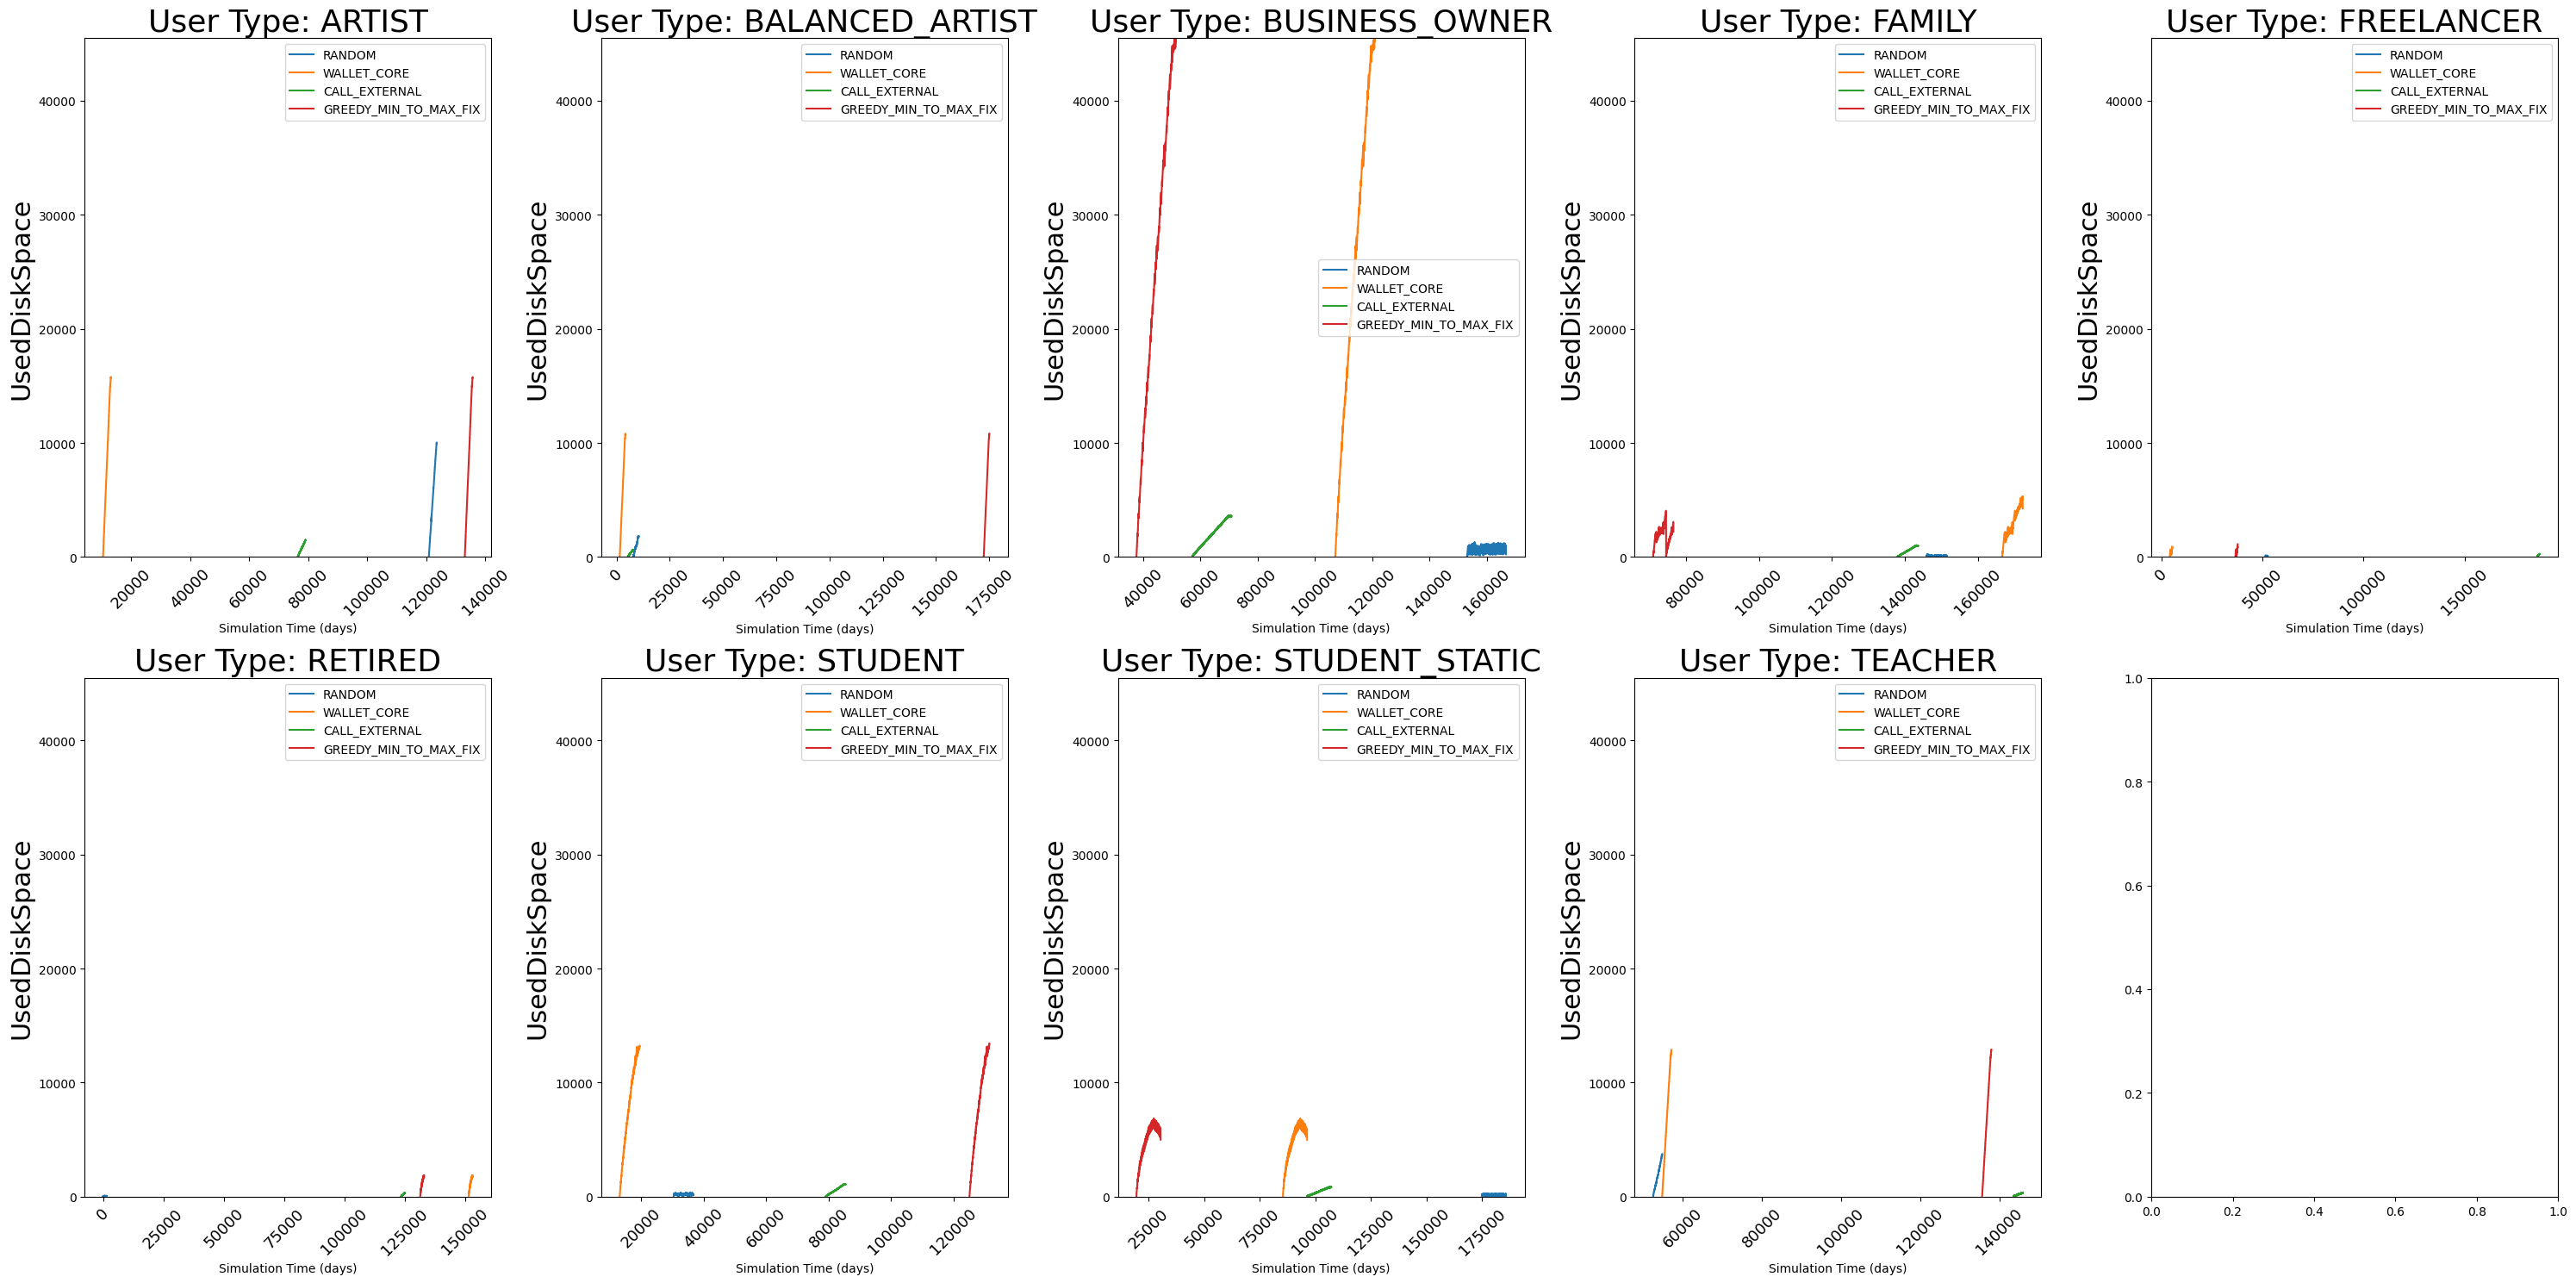

In [94]:
fig = plot_grid("UsedDiskSpace")

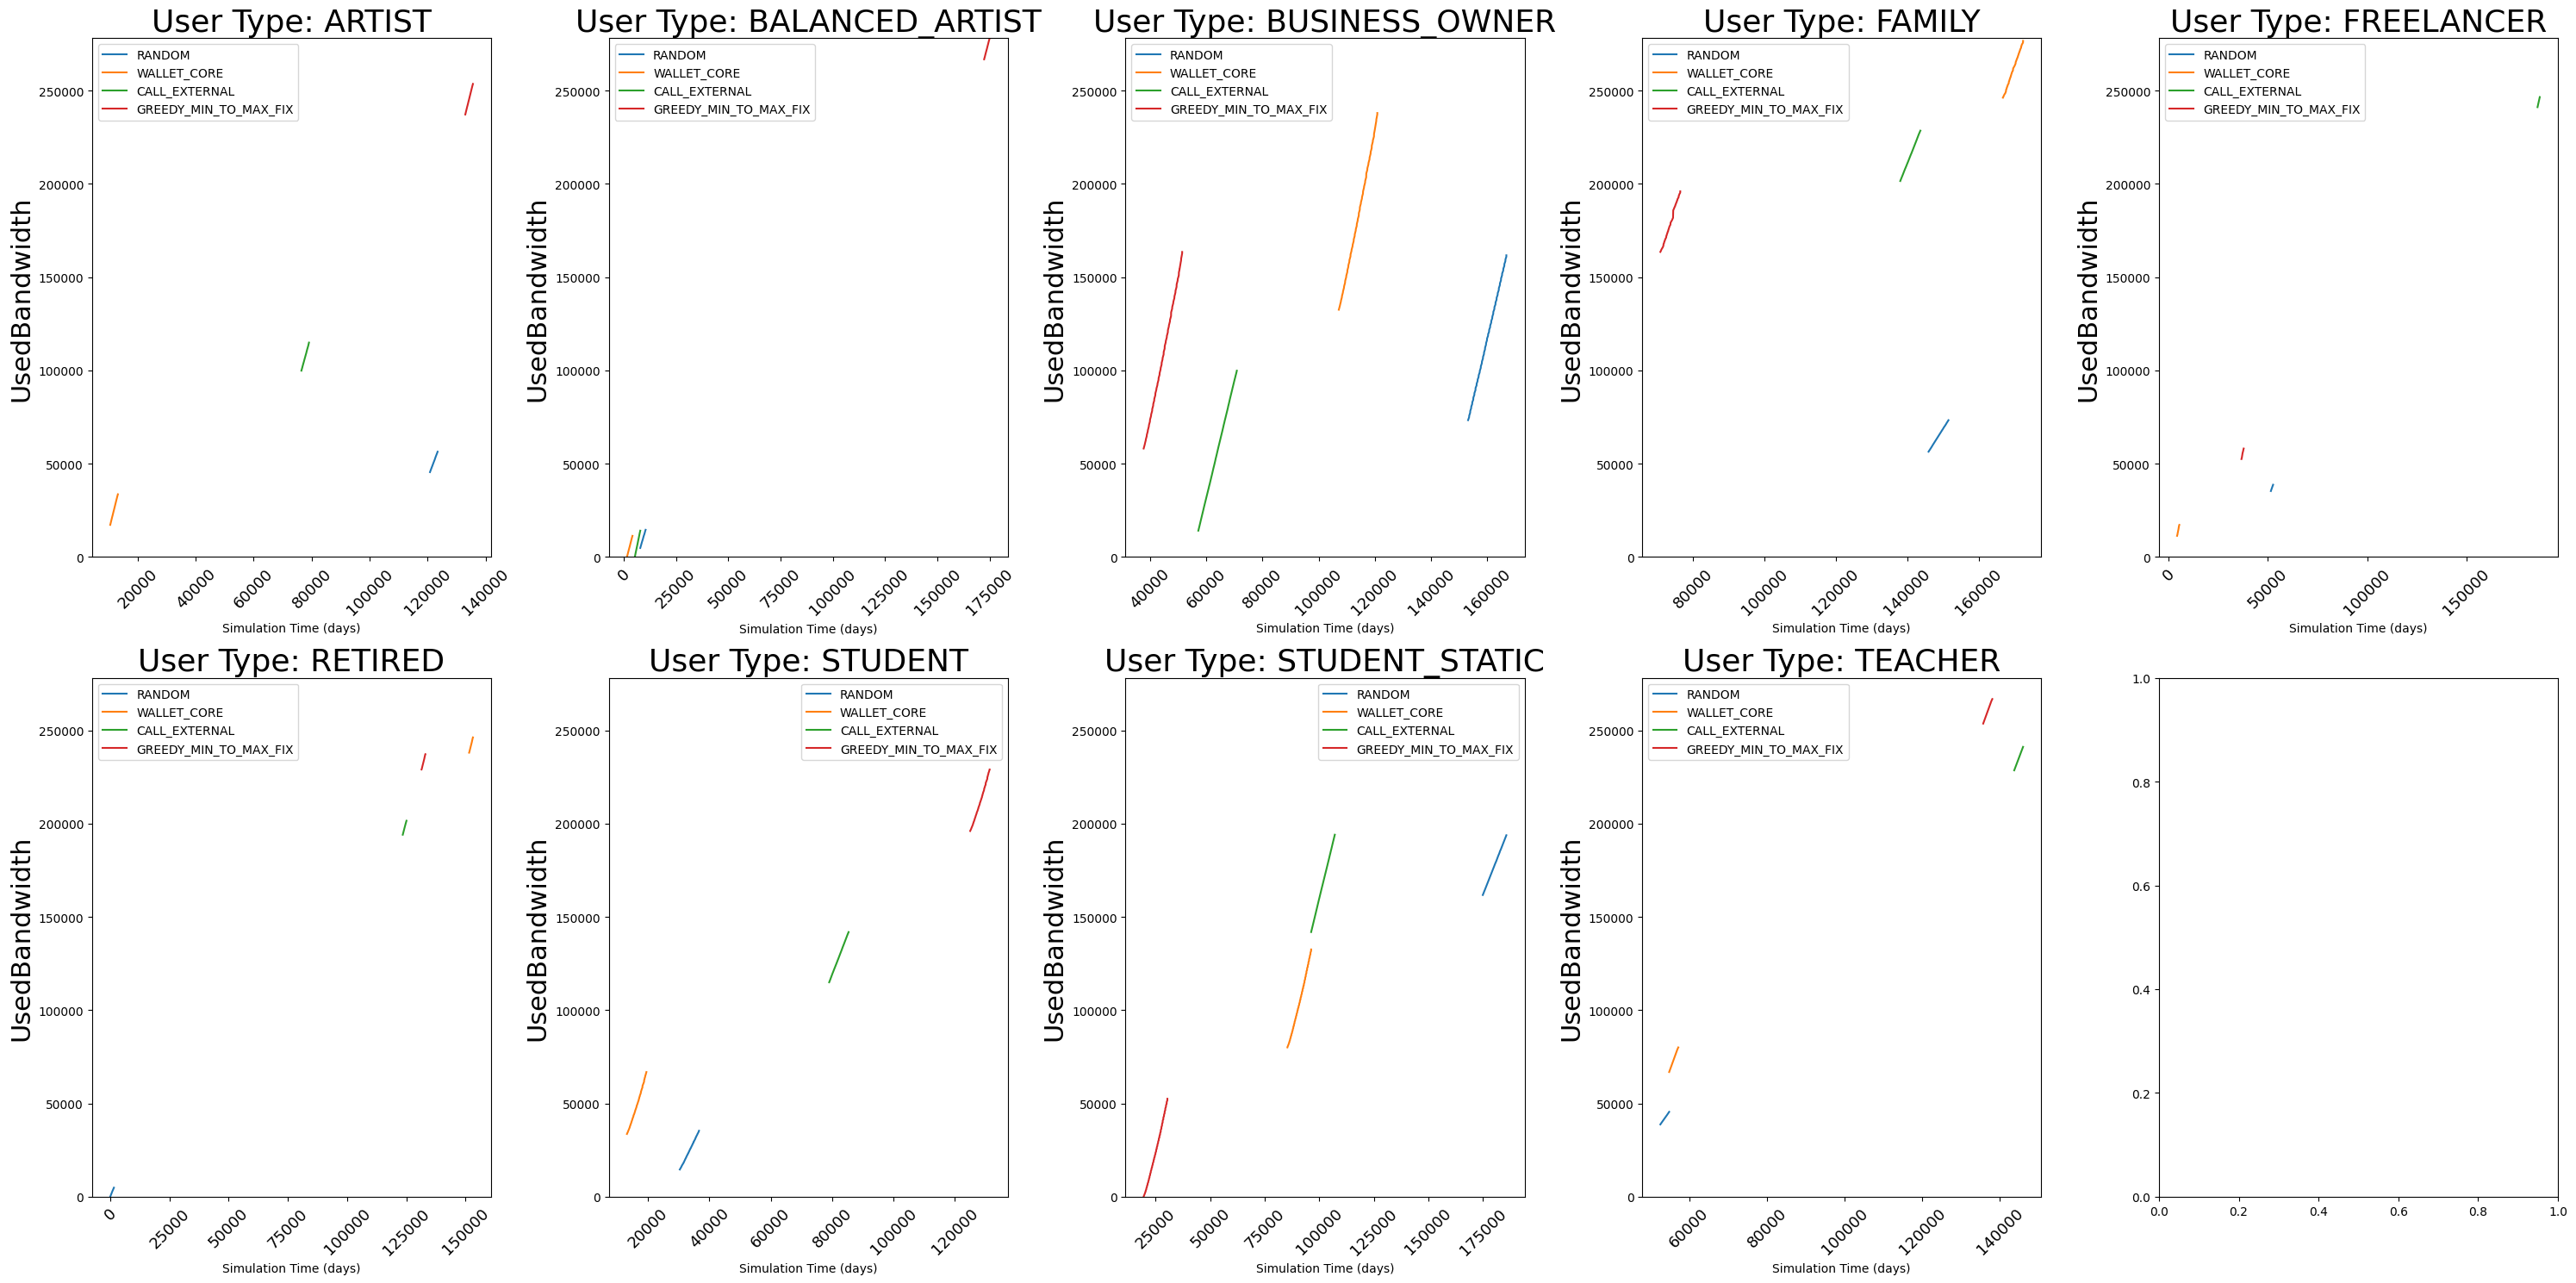

In [95]:
fig = plot_grid("UsedBandwidth")